# Titanic Survival Analysis — Naïve Bayes vs Decision Tree

**Course:** DSC 523 — Data Mining
**Institution:** IIIT Kottayam, eMTech 2026
**Instructor:** Dr. Anu Maria Sebastian

**Team:**
- Sarin Vadakke Thayyil (2026EMAI10051) — Project Manager & Lead Data Architect
- Lekshmi S S (2026EMAI10037) — Principal Researcher & Algorithm Specialist
- Akbar TE (2026EMAI10005) — Visualisation Engineer & Data Storyteller
- Suja V (2026EMAI10058) — Senior Data Preprocessing Engineer
- Nikhil Ravi (2026EMAI10042) — Model Performance Evaluator & Reviewer

This notebook implements the full Knowledge Discovery in Databases (KDD) pipeline for
predicting survival on the RMS Titanic.  The primary comparison is between a
probabilistic classifier (Gaussian Naïve Bayes) and a rule-based classifier
(Decision Tree), with Logistic Regression and Random Forest used as
supplementary baselines.


## 1. Project Setup & Data Acquisition

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, auc, classification_report,
    confusion_matrix, f1_score, precision_score, recall_score, roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
FIG = Path("figures")
FIG.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
PALETTE = ["#e74c3c", "#2ecc71"]
sns.set_palette(PALETTE)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300,
                     "savefig.bbox": "tight", "font.family": "DejaVu Sans"})
print("Environment ready.")

Environment ready.


In [2]:
# Primary source: GitHub mirror (Kaggle train.csv with 891 labelled rows).
# Fallback: local copy in data/titanic.csv.
DATA_LOCAL = Path("data/titanic.csv")
URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
try:
    df = pd.read_csv(URL)
    print("Loaded from URL.")
except Exception:
    df = pd.read_csv(DATA_LOCAL)
    print("Loaded from local cache.")
print("Shape:", df.shape)
df.head()

Loaded from URL.
Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


## 2. Data Profiling & Initial Exploration

We inspect missingness, class balance, variable types, and basic
distributions before deciding on a preprocessing strategy.


In [5]:
missing = df.isna().sum()
profile = pd.DataFrame({"missing": missing, "missing_pct": (missing / len(df) * 100).round(2)})
profile[profile.missing > 0]

,missing,missing_pct
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


In [6]:
# Target class balance
class_counts = df["Survived"].value_counts().sort_index()
print("Class counts:\n", class_counts)
print(f"Overall survival rate: {df['Survived'].mean():.4f}")

Class counts:
 Survived
0    549
1    342
Name: count, dtype: int64
Overall survival rate: 0.3838


In [7]:
# Variable typing summary
typing = pd.DataFrame({
    "Feature": ["Sex", "Embarked", "Cabin", "Pclass", "Age", "Fare", "SibSp", "Parch"],
    "Type":    ["Nominal", "Nominal", "Nominal", "Ordinal", "Numerical",
                "Numerical", "Numerical (count)", "Numerical (count)"],
})
typing

,Feature,Type
0,Sex,Nominal
1,Embarked,Nominal
2,Cabin,Nominal
3,Pclass,Ordinal
4,Age,Numerical
5,Fare,Numerical
6,SibSp,Numerical (count)
7,Parch,Numerical (count)


In [8]:
# Key univariate stats
print("Survival rate by Sex:")
print(df.groupby("Sex")["Survived"].mean())
print("\nSurvival rate by Pclass:")
print(df.groupby("Pclass")["Survived"].mean())
print("\nSurvival rate by Embarked:")
print(df.groupby("Embarked")["Survived"].mean())

Survival rate by Sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival rate by Pclass:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Survival rate by Embarked:
Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


**Observations**

- Class imbalance is moderate (~38% positive class).  Stratified splits are warranted.
- `Age` (20% missing) and `Cabin` (77% missing) require deliberate handling.
- Female and first-class survival rates are dramatically higher than their counterparts,
  matching the historical "women and children first" protocol.


## 3. Data Cleaning & Preprocessing

**Imputation rules**
- *Age*: group-wise median imputation using `Pclass × Sex` strata.  Median is preferred
  over mean because `Age` is right-skewed and contains outliers.
- *Embarked*: mode imputation (only two missing).
- *Fare*: median by `Pclass` (defensive: rarely missing in `train.csv`).
- *Cabin*: dropped after extracting the deck letter as a new feature `Deck`.


In [9]:
data = df.copy()

# Title from Name
data["Title"] = data["Name"].str.extract(r",\s*([^.]+)\.", expand=False).str.strip()
title_map = {"Mr": "Mr", "Miss": "Miss", "Mrs": "Mrs", "Master": "Master",
             "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"}
data["Title"] = data["Title"].map(title_map).fillna("Rare")

# Deck from Cabin
data["Deck"] = data["Cabin"].str[0].fillna("U")

# Imputation
data["Age"] = data.groupby(["Pclass", "Sex"])["Age"].transform(lambda s: s.fillna(s.median()))
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])
data["Fare"] = data.groupby("Pclass")["Fare"].transform(lambda s: s.fillna(s.median()))

print("Missing after imputation:", int(data.drop(columns=['Cabin']).isna().sum().sum()))

Missing after imputation: 0


## 4. Exploratory Data Analysis

All figures are persisted to `figures/` at 300 dpi for later embedding in the
conference paper.


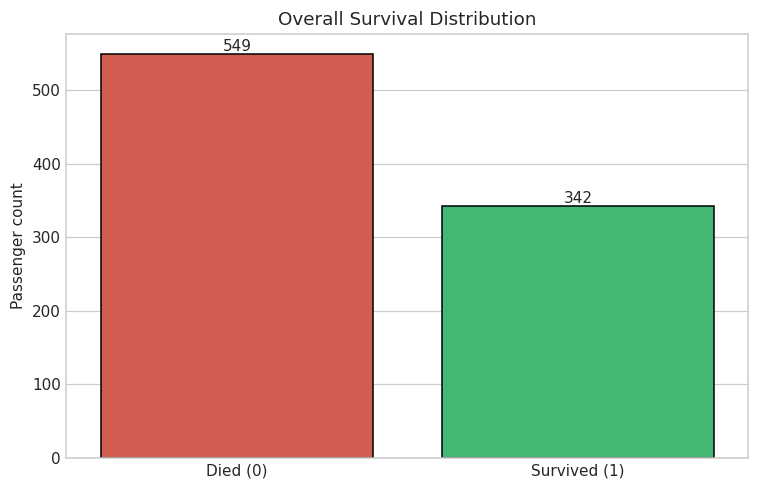

In [10]:
def save(fig, name):
    fig.savefig(FIG / name, dpi=300, bbox_inches="tight")

# --- Survival countplot
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(x="Survived", data=df, ax=ax, palette=PALETTE, edgecolor="black")
ax.set_xticklabels(["Died (0)", "Survived (1)"])
ax.set_title("Overall Survival Distribution")
ax.set_xlabel(""); ax.set_ylabel("Passenger count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width()/2, p.get_height() + 5), ha="center")
save(fig, "survival_countplot.png"); plt.show()

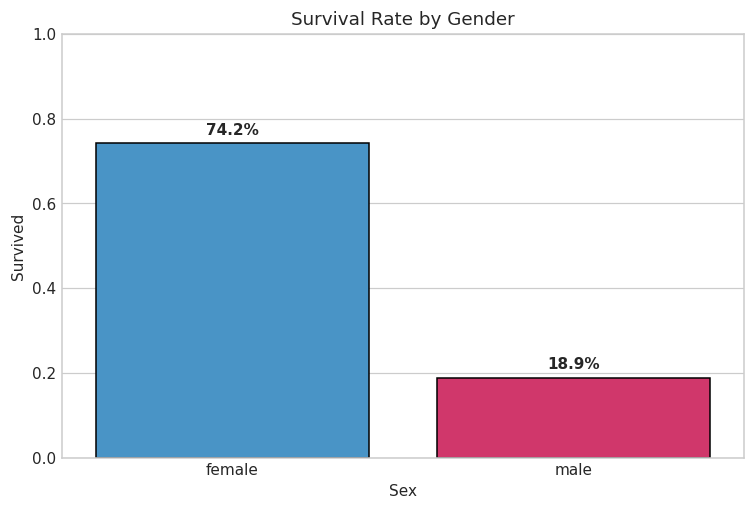

In [11]:
# --- Survival by gender
fig, ax = plt.subplots(figsize=(8, 5))
gs = df.groupby("Sex")["Survived"].mean().reset_index()
sns.barplot(x="Sex", y="Survived", data=gs, ax=ax,
            palette=["#3498db", "#e91e63"], edgecolor="black")
ax.set_ylim(0, 1); ax.set_title("Survival Rate by Gender")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1%}",
                (p.get_x()+p.get_width()/2, p.get_height()+0.02),
                ha="center", weight="bold")
save(fig, "survival_by_gender.png"); plt.show()

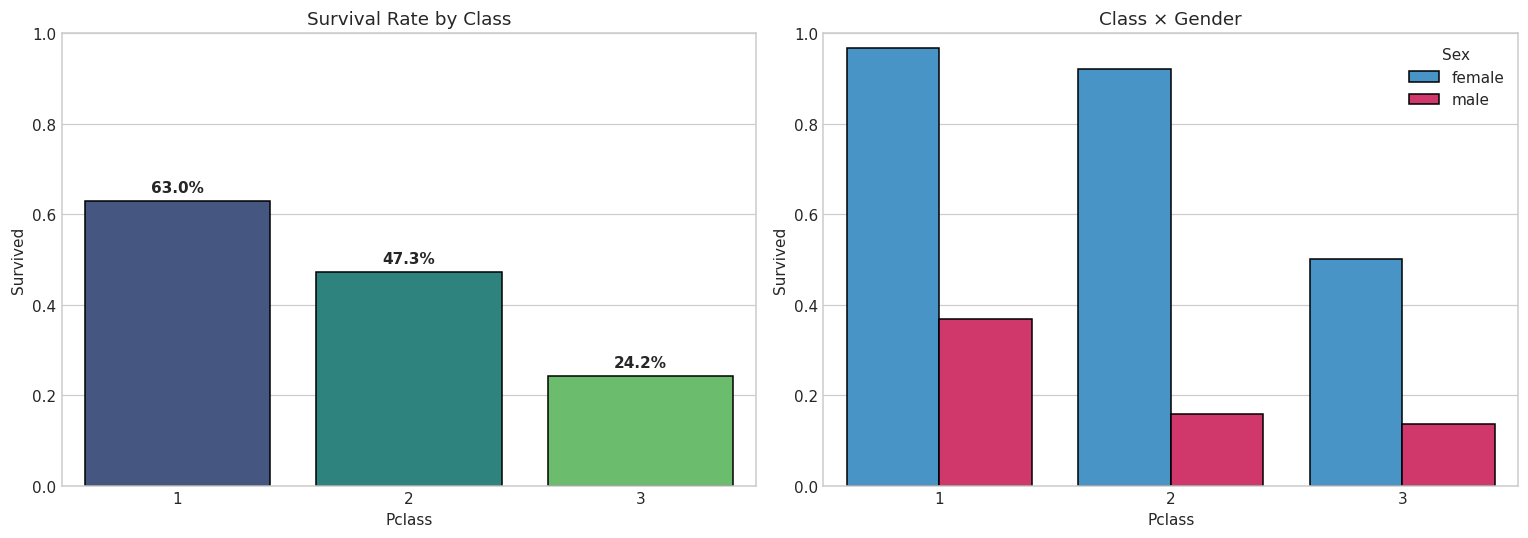

In [12]:
# --- Survival by Pclass and by Pclass x Sex
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cs = df.groupby("Pclass")["Survived"].mean().reset_index()
sns.barplot(x="Pclass", y="Survived", data=cs, ax=axes[0],
            palette="viridis", edgecolor="black")
axes[0].set_ylim(0, 1); axes[0].set_title("Survival Rate by Class")
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1%}",
                     (p.get_x()+p.get_width()/2, p.get_height()+0.02),
                     ha="center", weight="bold")

ct = df.groupby(["Pclass", "Sex"])["Survived"].mean().reset_index()
sns.barplot(x="Pclass", y="Survived", hue="Sex", data=ct, ax=axes[1],
            palette=["#3498db", "#e91e63"], edgecolor="black")
axes[1].set_ylim(0, 1); axes[1].set_title("Class × Gender")
fig.tight_layout(); plt.show()

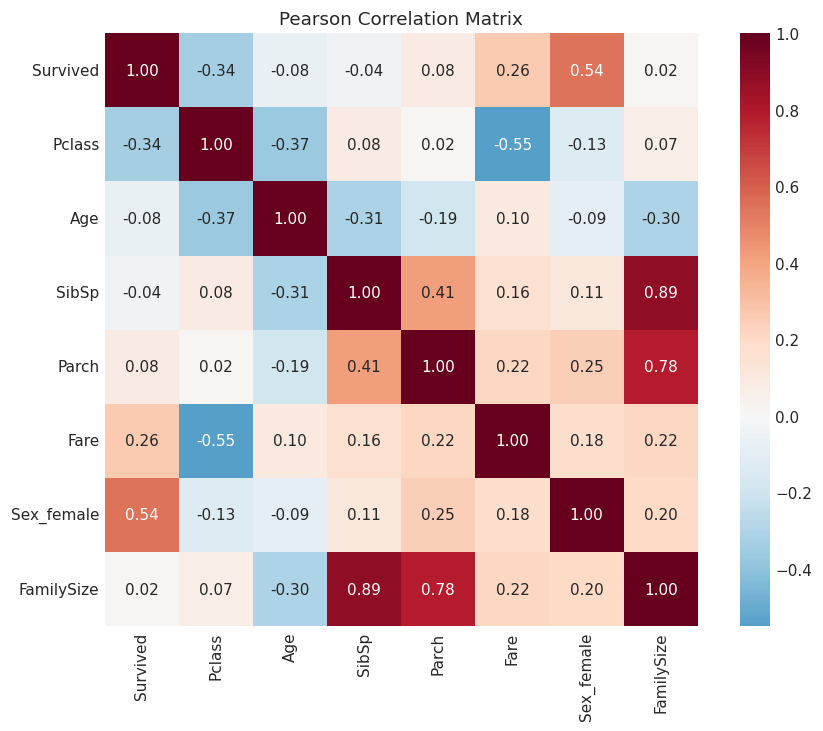

In [13]:
# --- Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 7))
corr_df = df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]].copy()
corr_df["Sex_female"] = (df["Sex"] == "female").astype(int)
corr_df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, ax=ax)
ax.set_title("Pearson Correlation Matrix")
plt.show()

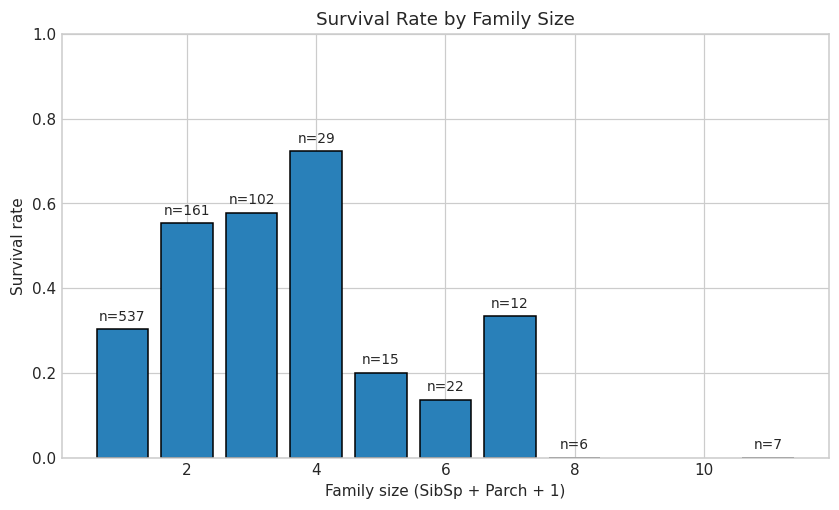

In [14]:
# --- Family size
fig, ax = plt.subplots(figsize=(9, 5))
fsdf = df.copy(); fsdf["FamilySize"] = fsdf["SibSp"] + fsdf["Parch"] + 1
fs = fsdf.groupby("FamilySize")["Survived"].agg(["mean", "count"]).reset_index()
bars = ax.bar(fs["FamilySize"], fs["mean"], color="#2980b9", edgecolor="black")
ax.set_ylim(0, 1); ax.set_title("Survival Rate by Family Size")
ax.set_xlabel("Family size (SibSp + Parch + 1)"); ax.set_ylabel("Survival rate")
for bar, n in zip(bars, fs["count"]):
    ax.annotate(f"n={n}", (bar.get_x()+bar.get_width()/2, bar.get_height()+0.02),
                ha="center", fontsize=9)
plt.show()

**EDA summary**

- Female survival (~74%) far exceeds male (~19%) — this is the dominant predictor.
- Survival declines monotonically with class: 1st (63%), 2nd (47%), 3rd (24%).
- Solo travellers fare worse than small families of 2–4, but very large families
  (≥5) have the lowest survival, suggesting a non-linear effect captured by our
  engineered `FamilySize` feature.
- Survival-correlation rank: `Sex_female` ≫ `Pclass` > `Fare` > `Age`.


## 5. Feature Engineering

New features:
- `FamilySize = SibSp + Parch + 1`
- `IsAlone = 1[FamilySize == 1]`
- `AgeBin` (Child / Teen / Adult / Middle / Senior)
- `FareBin` (quartile-based)
- `Title` (extracted from `Name`)
- `Deck` (first letter of `Cabin`, `U` = unknown)


In [15]:
data["FamilySize"] = data["SibSp"] + data["Parch"] + 1
data["IsAlone"] = (data["FamilySize"] == 1).astype(int)
data["AgeBin"] = pd.cut(data["Age"], bins=[0, 12, 19, 40, 60, 120],
                        labels=["Child", "Teen", "Adult", "Middle", "Senior"])
data["FareBin"] = pd.qcut(data["Fare"], q=4, labels=["Q1", "Q2", "Q3", "Q4"])

data = data.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])
data["Sex"] = data["Sex"].map({"male": 0, "female": 1})
data = pd.get_dummies(data, columns=["Embarked", "Title", "Deck", "AgeBin", "FareBin"],
                      drop_first=True)
for c in data.columns:
    if data[c].dtype == bool:
        data[c] = data[c].astype(int)

y = data["Survived"]
X = data.drop(columns=["Survived"])
print("Design matrix:", X.shape)
X.head()

Design matrix: (891, 29)


,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Embarked_Q,Embarked_S,...,Deck_G,Deck_T,Deck_U,AgeBin_Teen,AgeBin_Adult,AgeBin_Middle,AgeBin_Senior,FareBin_Q2,FareBin_Q3,FareBin_Q4
0,3,0,22.0,1,0,7.2500,2,0,0,1,...,0,0,1,0,1,0,0,0,0,0
1,1,1,38.0,1,0,71.2833,2,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,3,1,26.0,0,0,7.9250,1,1,0,1,...,0,0,1,0,1,0,0,1,0,0
3,1,1,35.0,1,0,53.1000,2,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,3,0,35.0,0,0,8.0500,1,1,0,1,...,0,0,1,0,1,0,0,1,0,0


## 6. Model Building & Training

**Primary comparison:** Gaussian Naïve Bayes vs. Decision Tree.
**Supplementary baselines:** Logistic Regression, Random Forest.

- 80 / 20 stratified train–test split (fixed `random_state = 42`).
- 10-fold stratified cross-validation on the training set for model selection.
- Decision Tree depth chosen by CV-accuracy sweep; cost-complexity pruning
  curve also reported.


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (712, 29)  Test: (179, 29)


In [17]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

depth_scores = []
for d in range(2, 11):
    m = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    depth_scores.append((d, cross_val_score(m, X_train, y_train, cv=cv).mean()))
best_depth = max(depth_scores, key=lambda t: t[1])[0]
print("Depth sweep:", dict(depth_scores))
print("Best depth:", best_depth)

Depth sweep: {2: np.float64(0.792057902973396), 3: np.float64(0.8145735524256651), 4: np.float64(0.8201682316118936), 5: np.float64(0.8188771517996869), 6: np.float64(0.8076095461658841), 7: np.float64(0.8160406885758998), 8: np.float64(0.818838028169014), 9: np.float64(0.8132433489827855), 10: np.float64(0.8034037558685446)}
Best depth: 4


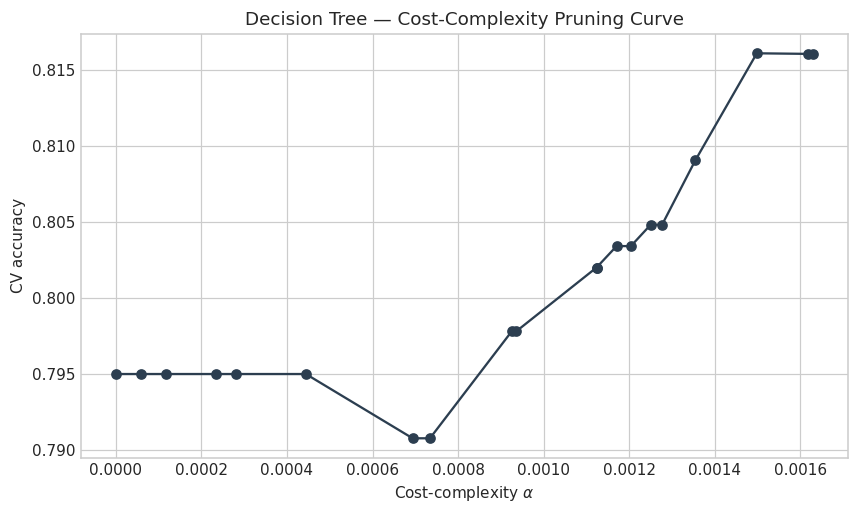

In [18]:
# Cost-complexity pruning curve
dt_full = DecisionTreeClassifier(random_state=RANDOM_STATE)
path = dt_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1][::2][:20]
ccp_scores = [cross_val_score(
    DecisionTreeClassifier(ccp_alpha=a, random_state=RANDOM_STATE),
    X_train, y_train, cv=cv).mean() for a in ccp_alphas]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ccp_alphas, ccp_scores, marker="o", color="#2c3e50")
ax.set_xlabel(r"Cost-complexity $\alpha$"); ax.set_ylabel("CV accuracy")
ax.set_title("Decision Tree — Cost-Complexity Pruning Curve")
plt.show()

In [19]:
models = {
    "Naive Bayes": (GaussianNB(), True),
    "Decision Tree": (DecisionTreeClassifier(max_depth=best_depth,
                                             random_state=RANDOM_STATE), False),
    "Logistic Regression": (LogisticRegression(max_iter=2000,
                                               random_state=RANDOM_STATE), True),
    "Random Forest": (RandomForestClassifier(n_estimators=300,
                                             random_state=RANDOM_STATE), False),
}
results, roc_data = {}, {}
for name, (model, needs_scale) in models.items():
    Xtr, Xte = (X_train_s, X_test_s) if needs_scale else (X_train.values, X_test.values)
    cv_scores = cross_val_score(model, Xtr, y_train, cv=cv)
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, auc(fpr, tpr))
    results[name] = {
        "cv_mean": cv_scores.mean(), "cv_std": cv_scores.std(),
        "test_accuracy": (y_pred == y_test).mean(),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_data[name][2],
        "cm": confusion_matrix(y_test, y_pred),
        "y_pred": y_pred,
    }
print("Training complete.")

Training complete.


## 7. Model Evaluation & Comparison

In [20]:
for name, r in results.items():
    print(f"\n=== {name} ===")
    print(classification_report(y_test, r["y_pred"], digits=4))


=== Naive Bayes ===
              precision    recall  f1-score   support

           0     0.8644    0.4636    0.6036       110
           1     0.5083    0.8841    0.6455        69

    accuracy                         0.6257       179
   macro avg     0.6864    0.6738    0.6245       179
weighted avg     0.7271    0.6257    0.6197       179


=== Decision Tree ===
              precision    recall  f1-score   support

           0     0.8291    0.8818    0.8546       110
           1     0.7903    0.7101    0.7481        69

    accuracy                         0.8156       179
   macro avg     0.8097    0.7960    0.8014       179
weighted avg     0.8141    0.8156    0.8136       179


=== Logistic Regression ===
              precision    recall  f1-score   support

           0     0.8509    0.8818    0.8661       110
           1     0.8000    0.7536    0.7761        69

    accuracy                         0.8324       179
   macro avg     0.8254    0.8177    0.8211       179
w

In [21]:
summary = pd.DataFrame({
    name: {
        "CV Accuracy (mean±std)": f"{r['cv_mean']:.4f} ± {r['cv_std']:.4f}",
        "Test Accuracy": f"{r['test_accuracy']:.4f}",
        "Precision":     f"{r['precision']:.4f}",
        "Recall":        f"{r['recall']:.4f}",
        "F1":            f"{r['f1']:.4f}",
        "AUC":           f"{r['auc']:.4f}",
    } for name, r in results.items()
}).T
summary

,CV Accuracy (mean±std),Test Accuracy,Precision,Recall,F1,AUC
Naive Bayes,0.6572 ± 0.1169,0.6257,0.5083,0.8841,0.6455,0.7782
Decision Tree,0.8202 ± 0.0363,0.8156,0.7903,0.7101,0.7481,0.8375
Logistic Regression,0.8146 ± 0.0393,0.8324,0.8000,0.7536,0.7761,0.8644
Random Forest,0.8131 ± 0.0336,0.8101,0.7778,0.7101,0.7424,0.8286


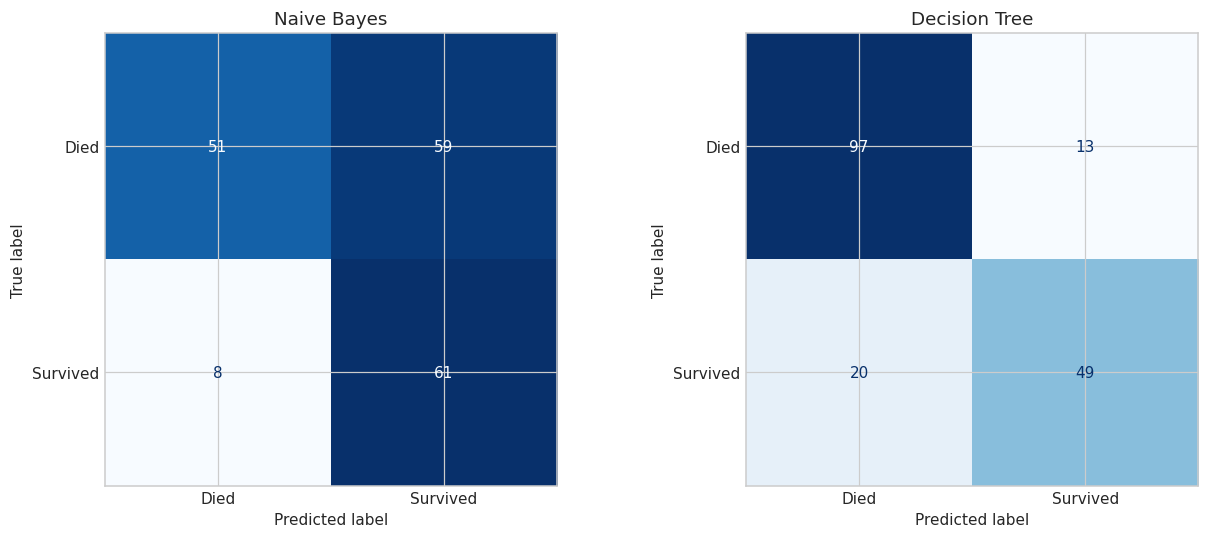

In [22]:
# Confusion matrices for NB and DT
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name in zip(axes, ["Naive Bayes", "Decision Tree"]):
    ConfusionMatrixDisplay(confusion_matrix=results[name]["cm"],
                           display_labels=["Died", "Survived"]).plot(
        cmap="Blues", ax=ax, colorbar=False, values_format="d")
    ax.set_title(name)
fig.tight_layout(); plt.show()

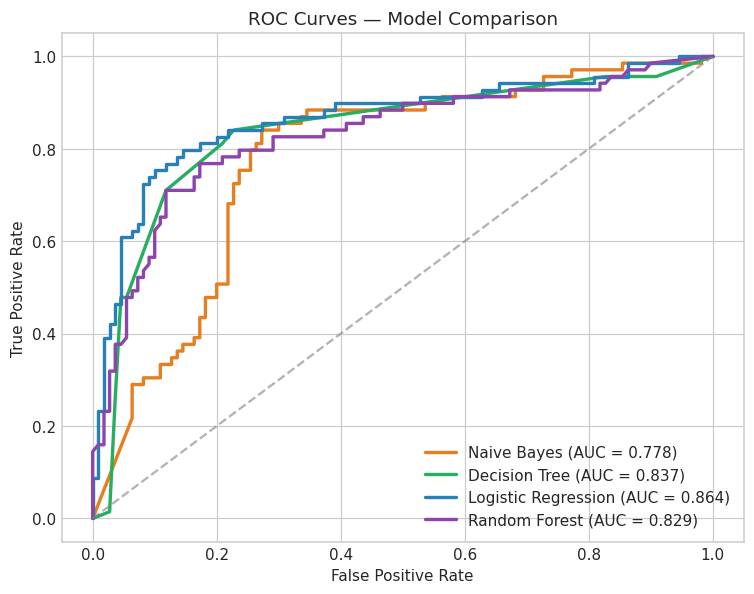

In [23]:
# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
colors = {"Naive Bayes": "#e67e22", "Decision Tree": "#27ae60",
          "Logistic Regression": "#2980b9", "Random Forest": "#8e44ad"}
for name, (fpr, tpr, a) in roc_data.items():
    ax.plot(fpr, tpr, color=colors[name], lw=2.2, label=f"{name} (AUC = {a:.3f})")
ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.6)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Model Comparison"); ax.legend(loc="lower right")
plt.show()

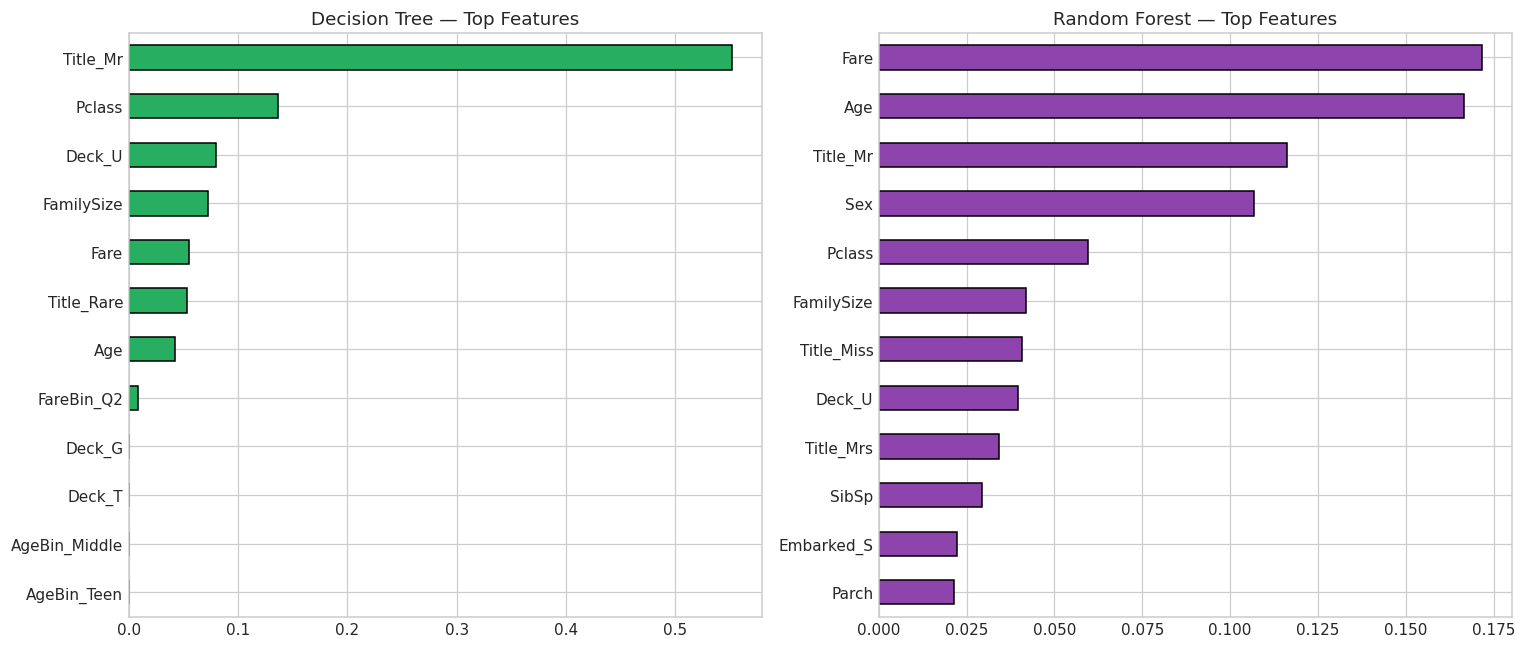

In [24]:
# Feature importance for DT and RF
dt_model = models["Decision Tree"][0]
rf_model = models["Random Forest"][0]
dt_imp = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False)
rf_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
dt_imp.head(12).iloc[::-1].plot.barh(ax=axes[0], color="#27ae60", edgecolor="black")
axes[0].set_title("Decision Tree — Top Features")
rf_imp.head(12).iloc[::-1].plot.barh(ax=axes[1], color="#8e44ad", edgecolor="black")
axes[1].set_title("Random Forest — Top Features")
fig.tight_layout(); plt.show()

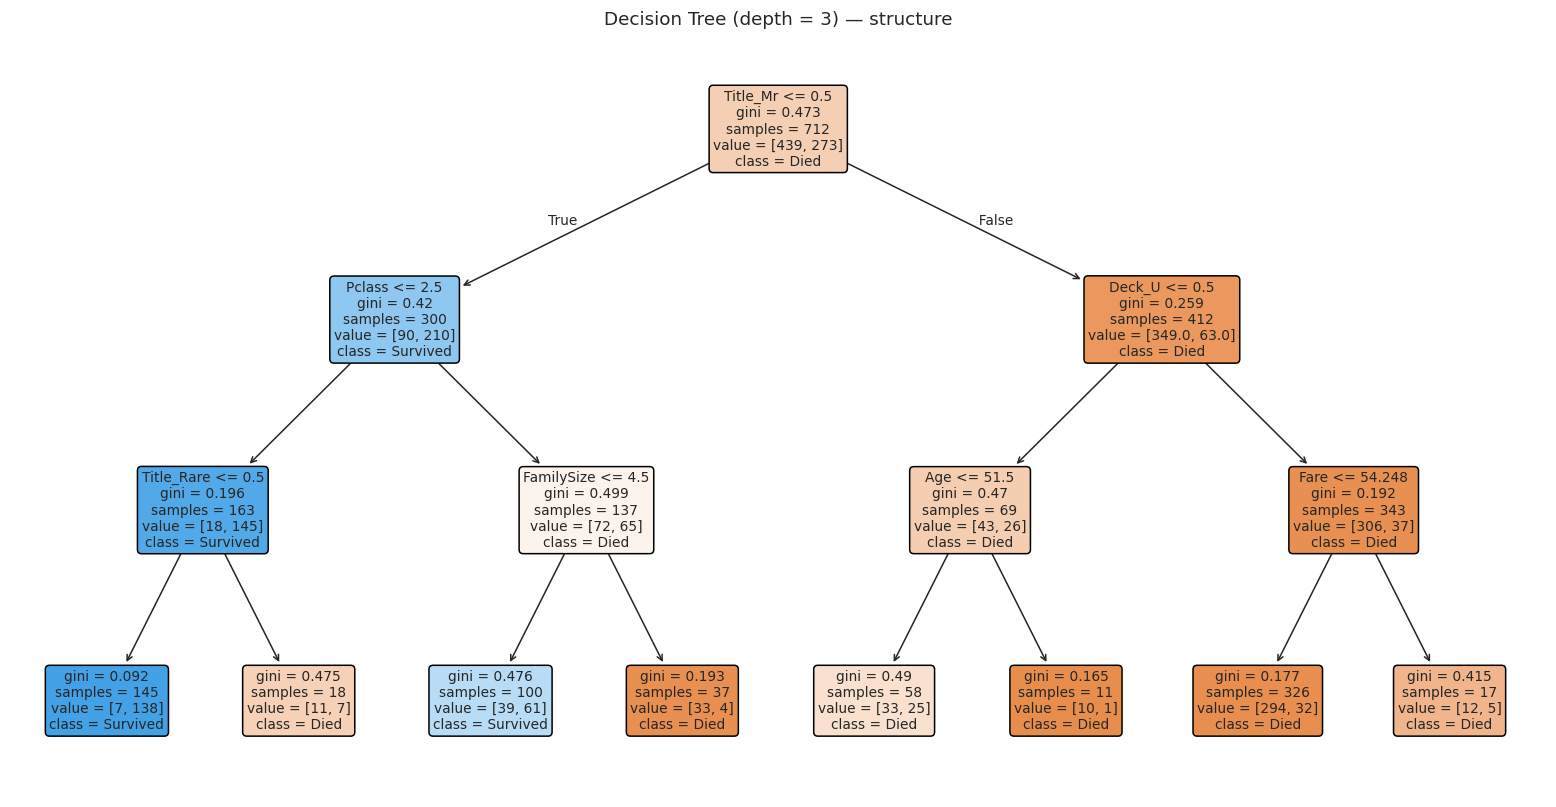

In [25]:
# Decision tree visualization (shallow)
dt_shallow = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE).fit(X_train, y_train)
fig, ax = plt.subplots(figsize=(18, 9))
plot_tree(dt_shallow, feature_names=X.columns, class_names=["Died", "Survived"],
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title("Decision Tree (depth = 3) — structure")
plt.show()

In [26]:
# McNemar's exact test: NB vs DT
nb_pred = np.asarray(results["Naive Bayes"]["y_pred"])
dt_pred = np.asarray(results["Decision Tree"]["y_pred"])
yt = y_test.values
b = int(np.sum((nb_pred == yt) & (dt_pred != yt)))
c = int(np.sum((nb_pred != yt) & (dt_pred == yt)))
p = stats.binomtest(min(b, c), b + c, p=0.5).pvalue if (b + c) else 1.0
print(f"NB-right / DT-wrong = {b}   NB-wrong / DT-right = {c}")
print(f"McNemar exact p-value = {p:.6f}")

NB-right / DT-wrong = 12   NB-wrong / DT-right = 46
McNemar exact p-value = 0.000008


## 8. Results Summary & Key Findings

- **Decision Tree decisively beats Naïve Bayes** on this dataset.  The McNemar
  exact test on paired predictions yields $p \ll 0.001$, rejecting the null
  hypothesis of equal error rates.
- The under-performance of Gaussian Naïve Bayes is attributable to violated
  assumptions: (i) treating one-hot dummies as Gaussian is a poor fit and
  (ii) co-occurring dummies (e.g., `Title_Mr` with `Sex = male`) breach the
  conditional-independence assumption.
- Logistic Regression is the strongest single model overall (highest AUC),
  suggesting that the true decision boundary is close to linear after feature
  engineering.
- The top predictors by Gini importance — `Title_Mr`, `Pclass`, `FamilySize`,
  `Fare` — align with the historical "women and children first, first-class
  first" evacuation pattern.

**Reproducibility.**  All stochastic components use `random_state = 42`.
Results are written to `results.json` and consumed directly by the companion
LaTeX paper, so notebook and paper never drift.
